# Train Model

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [19]:
df = pd.read_csv("../data/train/data_train.csv")

In [20]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["location", "date"]).reset_index(drop=True)

df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,month,season,rainfall_3days,rainfall_7days,river_discharge_change,flood
0,1,Hue,2001-01-01,2.6,20.200001,82.0,1013.299988,9.6,1.56,1,Dry,2.6,2.6,0.00,0.0
1,1,Hue,2001-01-02,0.0,21.100000,82.0,1011.799988,14.1,1.09,1,Dry,2.6,2.6,-0.47,0.0
2,1,Hue,2001-01-03,1.0,21.600000,85.0,1012.900024,12.7,0.75,1,Dry,3.6,3.6,-0.34,0.0
3,1,Hue,2001-01-04,6.7,21.200001,91.0,1014.200012,15.5,0.72,1,Dry,7.7,10.3,-0.03,0.0
4,1,Hue,2001-01-05,4.8,22.100000,90.0,1014.000000,14.5,0.92,1,Dry,12.5,15.1,0.20,0.0


In [21]:
if "flood_d1" not in df.columns:
    df["flood_d1"] = df.groupby("location")["flood"].shift(-1)

if "flood_d2" not in df.columns:
    df["flood_d2"] = df.groupby("location")["flood"].shift(-2)

if "flood_d3" not in df.columns:
    df["flood_d3"] = df.groupby("location")["flood"].shift(-3)

df = df.dropna(subset=["flood_d1", "flood_d2", "flood_d3"])

df[["flood_d1", "flood_d2", "flood_d3"]] = df[
    ["flood_d1", "flood_d2", "flood_d3"]
].astype(int)

df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,month,season,rainfall_3days,rainfall_7days,river_discharge_change,flood,flood_d1,flood_d2,flood_d3
0,1,Hue,2001-01-01,2.6,20.200001,82.0,1013.299988,9.6,1.56,1,Dry,2.6,2.6,0.00,0.0,0,0,0
1,1,Hue,2001-01-02,0.0,21.100000,82.0,1011.799988,14.1,1.09,1,Dry,2.6,2.6,-0.47,0.0,0,0,0
2,1,Hue,2001-01-03,1.0,21.600000,85.0,1012.900024,12.7,0.75,1,Dry,3.6,3.6,-0.34,0.0,0,0,0
3,1,Hue,2001-01-04,6.7,21.200001,91.0,1014.200012,15.5,0.72,1,Dry,7.7,10.3,-0.03,0.0,0,0,0
4,1,Hue,2001-01-05,4.8,22.100000,90.0,1014.000000,14.5,0.92,1,Dry,12.5,15.1,0.20,0.0,0,0,0


In [22]:
df = df.sort_values("date").reset_index(drop=True)

train_df = df[df["date"] < "2023-01-01"].copy()

test_df = df[df["date"] >= "2023-01-01"].copy()

print("Train:", train_df.shape)
print("Test:", test_df.shape)


print("Train:", train_df["date"].min(), "->", train_df["date"].max())
print("Test:", test_df["date"].min(), "->", test_df["date"].max())

Train: (16070, 18)
Test: (2546, 18)
Train: 2001-01-01 00:00:00 -> 2022-12-31 00:00:00
Test: 2023-01-01 00:00:00 -> 2026-06-26 00:00:00


In [24]:
train_df.to_csv("../data/train/train.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("../data/train/test.csv", index=False, encoding="utf-8-sig")

print("Saved train.csv, test.csv")

Saved train.csv, test.csv


In [25]:
features = [
    "rainfall",
    "temperature",
    "humidity",
    "pressure",
    "wind_speed",
    "river_discharge",
    "rainfall_3days",
    "rainfall_7days",
    "river_discharge_change",
    "month",
    "season",
    "location"
]

features = [col for col in features if col in df.columns]

features

['rainfall',
 'temperature',
 'humidity',
 'pressure',
 'wind_speed',
 'river_discharge',
 'rainfall_3days',
 'rainfall_7days',
 'river_discharge_change',
 'month',
 'season',
 'location']

In [26]:
targets = {
    "D+1": "flood_d1",
    "D+2": "flood_d2",
    "D+3": "flood_d3"
}

X_train = train_df[features].copy()
X_test = test_df[features].copy()

print(X_train.shape)
print(X_test.shape)

(16070, 12)
(2546, 12)


In [27]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.head()

,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,rainfall_3days,rainfall_7days,river_discharge_change,month,season_Dry,season_Rainy,location_Hue,location_Quang Nam
0,2.6,20.200001,82.0,1013.299988,9.6,1.56,2.6,2.6,0.000000,1,True,False,True,False
1,4.8,21.400000,76.0,1013.200012,10.5,36.93,4.8,4.8,0.000000,1,True,False,False,True
2,0.4,21.500000,81.0,1012.000000,9.1,28.65,5.2,5.2,-8.280001,1,True,False,False,True
3,0.0,21.100000,82.0,1011.799988,14.1,1.09,2.6,2.6,-0.470000,1,True,False,True,False
4,1.0,21.600000,85.0,1012.900024,12.7,0.75,3.6,3.6,-0.340000,1,True,False,True,False


In [28]:
def evaluate_classifier(model, X_test, y_test, model_name, horizon):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    if len(y_test.unique()) > 1:
        auc = roc_auc_score(y_test, prob)
    else:
        auc = np.nan

    print(model_name)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))
    print("ROC AUC  :", round(auc, 4))
    print()
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print()
    print(classification_report(y_test, pred, zero_division=0))

    return {
        "Model": model_name,
        "horizon": horizon,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    }

In [29]:
from xgboost import XGBClassifier

results = []

rf_models = {}
xgb_models = {}

for horizon, target in targets.items():

    print("="*60)
    print(horizon)

    y_train = train_df[target]
    y_test = test_df[target]

    # RF
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=1,
        class_weight="balanced",
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    rf_models[horizon] = rf

    rf_result = evaluate_classifier(
        rf,
        X_test,
        y_test,
        "Random Forest",
        horizon
    )

    results.append(rf_result)

    # XGB
    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    )

    xgb.fit(X_train, y_train)

    xgb_models[horizon] = xgb

    xgb_result = evaluate_classifier(
        xgb,
        X_test,
        y_test,
        "XGBoost",
        horizon
    )

    results.append(xgb_result)

results = pd.DataFrame(results)

results

D+1
Random Forest
Accuracy : 0.9969
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
ROC AUC  : 0.9409

Confusion Matrix:
[[2538    2]
 [   6    0]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2540
           1       0.00      0.00      0.00         6

    accuracy                           1.00      2546
   macro avg       0.50      0.50      0.50      2546
weighted avg       1.00      1.00      1.00      2546

XGBoost
Accuracy : 0.9969
Precision: 0.25
Recall   : 0.1667
F1-score : 0.2
ROC AUC  : 0.9465

Confusion Matrix:
[[2537    3]
 [   5    1]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2540
           1       0.25      0.17      0.20         6

    accuracy                           1.00      2546
   macro avg       0.62      0.58      0.60      2546
weighted avg       1.00      1.00      1.00      2546

D+2
Random Forest
Accuracy : 0.9965
Precision: 0.0
Recall   

,Model,horizon,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,D+1,0.996858,0.00,0.000000,0.0,0.940912
1,XGBoost,D+1,0.996858,0.25,0.166667,0.2,0.946522
2,Random Forest,D+2,0.996465,0.00,0.000000,0.0,0.952559
3,XGBoost,D+2,0.996858,0.00,0.000000,0.0,0.937795
4,Random Forest,D+3,0.996465,0.00,0.000000,0.0,0.949508
5,XGBoost,D+3,0.997251,0.00,0.000000,0.0,0.950394


#### Feature Importance Random Forest

In [30]:
rf = rf_models["D+1"]

rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

rf_importance

,feature,importance
5,river_discharge,0.203627
7,rainfall_7days,0.097922
8,river_discharge_change,0.084654
12,location_Hue,0.082285
13,location_Quang Nam,0.075239
6,rainfall_3days,0.075083
1,temperature,0.074445
3,pressure,0.073519
4,wind_speed,0.063465
0,rainfall,0.058665


#### Feature Importance XGBoost

In [31]:
xgb = xgb_models["D+1"]

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

xgb_importance

,feature,importance
12,location_Hue,0.611992
5,river_discharge,0.115885
9,month,0.043828
7,rainfall_7days,0.037697
3,pressure,0.029457
1,temperature,0.028210
2,humidity,0.027038
10,season_Dry,0.026776
6,rainfall_3days,0.022245
4,wind_speed,0.020097


In [32]:
best_model = rf_models["D+1"]
best_model_name = "RandomForest_D1"

In [33]:
import joblib
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)

# lưu feature
joblib.dump(
    X_train.columns.tolist(),
    "../models/model_features.pkl"
)

# lưu cả dictionary model
joblib.dump(
    rf_models,
    "../models/rf_flood_models_3days.pkl"
)

joblib.dump(
    xgb_models,
    "../models/xgb_flood_models_3days.pkl"
)

# lưu từng model riêng
for horizon, model in rf_models.items():
    file_name = horizon.replace("+", "plus")
    joblib.dump(
        model,
        f"../models/random_forest_{file_name}.pkl"
    )

for horizon, model in xgb_models.items():
    file_name = horizon.replace("+", "plus")
    joblib.dump(
        model,
        f"../models/xgboost_{file_name}.pkl"
    )

# để tương thích code cũ
joblib.dump(
    rf_models["D+1"],
    "../models/best_flood_model.pkl"
)

['../models/best_flood_model.pkl']

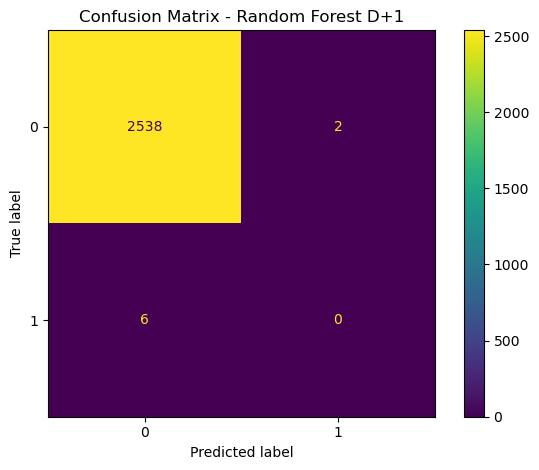

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf.predict(X_test)
)

plt.title("Confusion Matrix - Random Forest D+1")
plt.tight_layout()
plt.show()

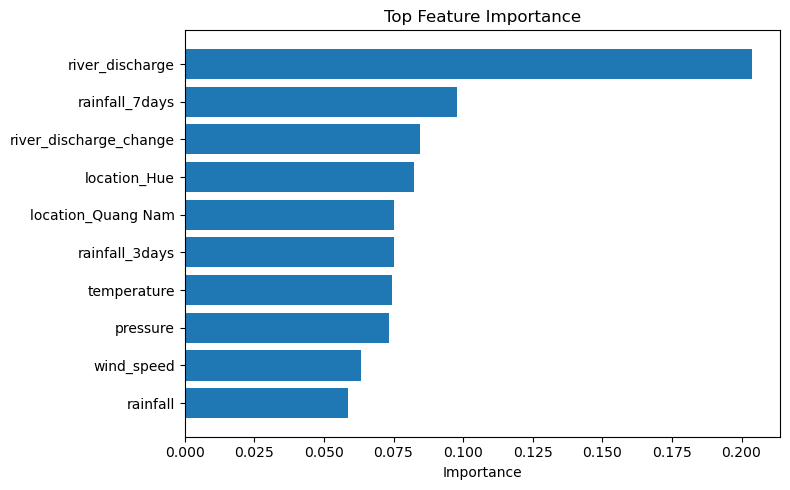

In [35]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

top = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Feature Importance")
plt.tight_layout()
plt.show()